# Machine Learning 1 - NHANES Depression - Anwendung -> Gesund/Krank



**🏥 Die spannende Frage:** Kann ein Computer Herzkrankheiten erkennen?

**Lernziele:**
- ML in der Medizin anwenden
- Welche Risikofaktoren sind wichtig?
- Verschiedene Algorithmen vergleichen
- Warum sind Fehler in der Medizin kritisch?

**Bearbeitungszeit:** ca. 60 Minuten

# Disclaimer:
das ist kein "aufgeräumtes Skript". ich habe ML-Codes aus Lektion 9 und 10 auf meinem Datensatz ausprobiert und bin schnell zum Schluss gekommen, dass die Vorherasage (wahrscheinlich aufgrund des geringen Anteils kranker Probanden im Datensatz und der generell sehr niedrigen Korrelation der features mit der Targest Variable) nicht ausreichend präzise ist und deshalb den optionalen Part ML optional sein lassen. 
Deshalb sind hier noch manche fehlerhafte Ansätze enthalten, wie etwa der Nutzung eigentlich kategorialer Variablen als numerischer (bei der Confusion-Matrix ist das über One-Hot-Encoding behoben).

## Dataset: NHANES Datensatz eigene Kombination

~~**297 Patienten** aus Cleveland Clinic mit Messungen zu:~~
- Alter, Geschlecht, Blutdruck, Cholesterin
- Herzfrequenz, EKG-Werte, Brustschmerz-Typ

~**Ziel:** Vorhersage ob Herzkrankheit vorliegt (condition: 0=gesund, 1=krank)~



## Teil 1: Setup

In [1]:
# Bibliotheken
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# Visualisierung
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print(" Setup komplett")

 Setup komplett


In [2]:
# Daten laden (bereinigte Version aus Woche 7)
df = pd.read_csv('NHANES_depression.csv')

print(f" Datensatz: {df.shape[0]} Probanden, {df.shape[1]} Features")
print(f"\n Erste 5 Zeilen:")
display(df.head())

print("Erläuterungen:")

 Datensatz: 5441 Probanden, 29 Features

 Erste 5 Zeilen:


,SEQN,RIAGENDR,RIDAGEYR,DMDEDUC2,DMDMARTZ,BMXBMI,OCD150,SLD012,SLD013,PAD790Q,...,DPQ050,DPQ060,DPQ070,DPQ080,DPQ090,PHQ9,DEPS,ASH,MEMPW,DEPT
0,130379,1,66,5,1,33.5,1,9.0,9.0,4.0,...,0,0,0,0,0,1,0,9.000000,450.000000,0
1,130380,2,44,3,1,29.7,1,8.0,9.0,1.0,...,0,0,0,0,0,2,0,8.285714,20.000000,0
2,130386,1,34,4,1,30.2,1,7.5,8.0,1.0,...,0,1,0,0,0,1,0,7.642857,43.793103,0
3,130387,2,68,5,3,42.6,4,3.0,5.0,0.0,...,0,0,0,0,0,0,0,3.571429,0.000000,0
4,130389,1,59,5,1,28.0,1,8.0,8.0,3.0,...,0,0,0,0,0,0,0,8.000000,162.586207,0


Erläuterungen:


zu viele Features. Erstmal auf die wichtigen filtern. zB nurnoch Gesamtscore für Depression.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5441 entries, 0 to 5440
Data columns (total 29 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   SEQN      5441 non-null   int64  
 1   RIAGENDR  5441 non-null   int64  
 2   RIDAGEYR  5441 non-null   int64  
 3   DMDEDUC2  5441 non-null   int64  
 4   DMDMARTZ  5441 non-null   int64  
 5   BMXBMI    5441 non-null   float64
 6   OCD150    5441 non-null   int64  
 7   SLD012    5441 non-null   float64
 8   SLD013    5441 non-null   float64
 9   PAD790Q   5441 non-null   float64
 10  PAD790U   4399 non-null   str    
 11  PAD800    5441 non-null   float64
 12  PAD810Q   5441 non-null   float64
 13  PAD810U   2570 non-null   str    
 14  PAD820    5441 non-null   float64
 15  DPQ010    5441 non-null   int64  
 16  DPQ020    5441 non-null   int64  
 17  DPQ030    5441 non-null   int64  
 18  DPQ040    5441 non-null   int64  
 19  DPQ050    5441 non-null   int64  
 20  DPQ060    5441 non-null   int64  
 21  DP

important_columns = ['SEQN','RIAGENDR','RIDAGEYR','DMDEDUC2','DMDMARTZ','BMXBMI', \
                     'DEPS','ASH','MEMPW']
df_ML = df[important_columns]
df_ML.head()

df_ML["DEPS"] = df_ML["DEPS"].map({
    'keine/minimale Symptomatik': 0,
    'leichte Symptomatik': 1,
    'behandlungsbedürftig (>=10)': 2
})

df_ML['DEPS'].unique()

df_ML['DEPT'] = df_ML['DEPS'].replace({
     0 : 0,
     1 : 0,
     2 : 1
})

In [4]:
df_ML = df

In [5]:
df_ML = df_ML.drop(columns=['DEPS'])

In [6]:
df_ML = df_ML.drop(columns=['SEQN'])

In [7]:
to_drop = ['DPQ010', 'DPQ020', 'DPQ030', 'DPQ040', 'DPQ050', 'DPQ060', 'DPQ070', 'DPQ080', \
          'DPQ090', 'PHQ9']
df_ML = df_ML.drop(columns=to_drop)

In [8]:
to_drop = [ 'PAD790Q','SLD012','PAD800', 'PAD820','PAD810Q', 'SLD013']
df_ML = df_ML.drop(columns=to_drop)

In [9]:
df_ML.head()

,RIAGENDR,RIDAGEYR,DMDEDUC2,DMDMARTZ,BMXBMI,OCD150,PAD790U,PAD810U,ASH,MEMPW,DEPT
0,1,66,5,1,33.5,1,W,W,9.000000,450.000000,0
1,2,44,3,1,29.7,1,W,NaN,8.285714,20.000000,0
2,1,34,4,1,30.2,1,W,M,7.642857,43.793103,0
3,2,68,5,3,42.6,4,NaN,NaN,3.571429,0.000000,0
4,1,59,5,1,28.0,1,W,M,8.000000,162.586207,0


## Teil 2: Explorative Analyse - Wie viele sind krank?

**Wichtig für ML:** Ist das Dataset balanciert?

 Verteilung Gesund vs. Krank:
DEPT
0    4724
1     717
Name: count, dtype: int64

Anteil krank: 13.2%


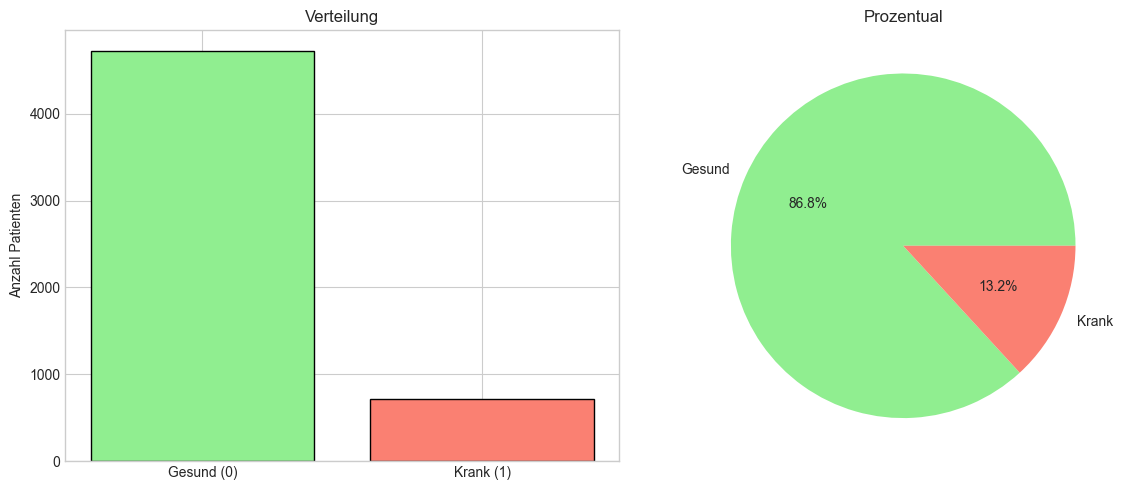


 Dataset balanciert genug für ML?


In [10]:
# Target-Verteilung
print(" Verteilung Gesund vs. Krank:")
print(df_ML['DEPT'].value_counts())
print(f"\nAnteil krank: {df_ML['DEPT'].mean():.1%}")

# Visualisierung
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

condition_counts = df_ML['DEPT'].value_counts()
ax[0].bar(['Gesund (0)', 'Krank (1)'], condition_counts.values, 
          color=['lightgreen', 'salmon'], edgecolor='black')
ax[0].set_ylabel('Anzahl Patienten')
ax[0].set_title('Verteilung')

ax[1].pie(condition_counts.values, labels=['Gesund', 'Krank'], 
          autopct='%1.1f%%', colors=['lightgreen', 'salmon'])
ax[1].set_title('Prozentual')

plt.tight_layout()
plt.show()

print("\n Dataset balanciert genug für ML?")

## Teil 3: Feature Selection - Welche Risikofaktoren sind wichtig?

**Die spannende Frage:** Was erhöht das Risiko für Herzkrankheiten?

 Korrelation mit Depression:
DMDMARTZ    0.081210
RIAGENDR    0.072886
BMXBMI      0.065185
OCD150      0.061878
DMDEDUC2   -0.015352
MEMPW      -0.033686
ASH        -0.043380
RIDAGEYR   -0.129436
Name: DEPT, dtype: float64


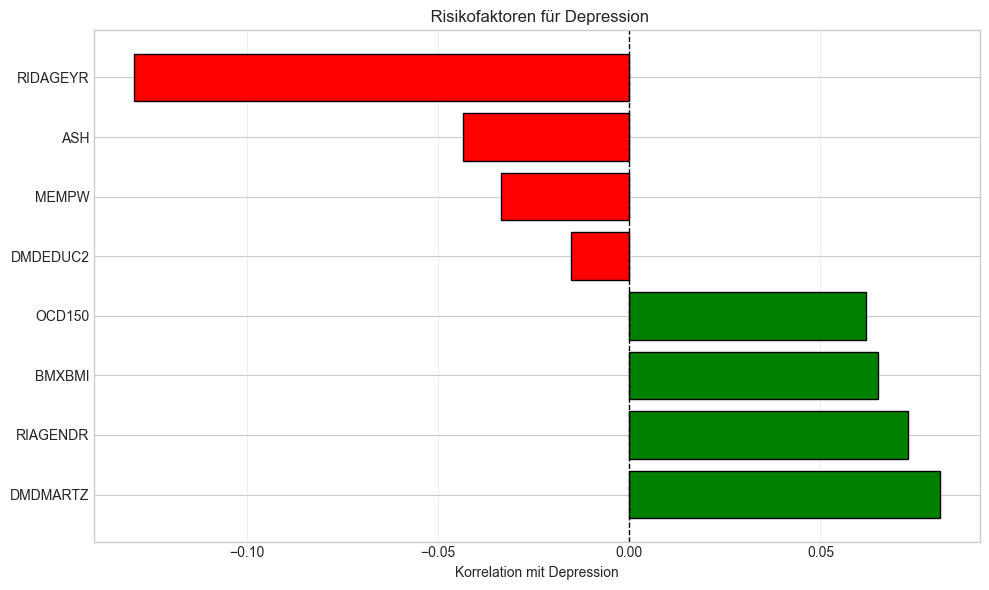


Größtes Risiko (positiv): DMDMARTZ (0.08)
   → Höhere Werte = höheres Krankheitsrisiko (z.B. Blutprobleme belasten Herz)

 Größter Schutz (negativ): RIDAGEYR (-0.13)
   → Höhere Werte = niedrigeres Risiko (z.B. hohe max. Herzfrequenz = fit)

 Merke: Korrelation zeigt statistische Zusammenhänge, nicht Ursache!


In [11]:
# TODO: Berechne Korrelation mit 'condition'
# DEIN CODE HIER

# Nur numerische Spalten für Korrelation
target_corr = df_ML.corr(numeric_only=True)['DEPT'].sort_values(ascending=False)

print(" Korrelation mit Depression:")
print(target_corr[1:])  # Ohne condition selbst

# Visualisierung
plt.figure(figsize=(10, 6))
corr_plot = target_corr[1:]  # Ohne condition
colors = ['green' if x > 0 else 'red' for x in corr_plot.values]
plt.barh(range(len(corr_plot)), corr_plot.values, color=colors, edgecolor='black')
plt.yticks(range(len(corr_plot)), corr_plot.index)
plt.xlabel('Korrelation mit Depression')
plt.title(' Risikofaktoren für Depression')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nGrößtes Risiko (positiv): {target_corr.index[1]} ({target_corr.values[1]:.2f})")
print(f"   → Höhere Werte = höheres Krankheitsrisiko (z.B. Blutprobleme belasten Herz)")

print(f"\n Größter Schutz (negativ): {target_corr.index[-1]} ({target_corr.values[-1]:.2f})")  
print(f"   → Höhere Werte = niedrigeres Risiko (z.B. hohe max. Herzfrequenz = fit)")

print("\n Merke: Korrelation zeigt statistische Zusammenhänge, nicht Ursache!")

## Teil 4: Daten für ML vorbereiten

In [12]:
# Features (X) und Target (y)
y = df_ML['DEPT']
X = df_ML.drop('DEPT', axis=1).select_dtypes(include=['int64', 'float64'])

print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape}")
print(f"\n Verwendete Features: {X.columns.tolist()}")
print(f"\n Nur numerische Features werden verwendet (Text-Spalten ignoriert)")

print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape}")
print(f"\n Alle Features: {X.columns.tolist()}")

Features (X): (5441, 8)
Target (y): (5441,)

 Verwendete Features: ['RIAGENDR', 'RIDAGEYR', 'DMDEDUC2', 'DMDMARTZ', 'BMXBMI', 'OCD150', 'ASH', 'MEMPW']

 Nur numerische Features werden verwendet (Text-Spalten ignoriert)
Features (X): (5441, 8)
Target (y): (5441,)

 Alle Features: ['RIAGENDR', 'RIDAGEYR', 'DMDEDUC2', 'DMDMARTZ', 'BMXBMI', 'OCD150', 'ASH', 'MEMPW']


In [13]:
# TODO: Train/Test Split (80/20, stratified)
# DEIN CODE HIER

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Erhält Verteilung
)

print(f"Training Set: {len(X_train)} Patienten ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test Set: {len(X_test)} Patienten ({len(X_test)/len(X)*100:.0f}%)")
print(f"\nTarget-Verteilung bleibt gleich: {y_test.mean():.1%} krank")

Training Set: 4352 Patienten (80%)
Test Set: 1089 Patienten (20%)

Target-Verteilung bleibt gleich: 13.2% krank


## Teil 5: Modellvergleich - Welcher Algorithmus ist am besten?

In [14]:
from sklearn.neighbors import NearestCentroid, KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

# TODO: Definiere Modelle
# DEIN CODE HIER

models = {
    'Nearest Centroid': NearestCentroid(),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes': GaussianNB()
}

print(f"✓ {len(models)} Modelle definiert")

✓ 6 Modelle definiert


In [15]:
# Trainieren und Evaluieren
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    
    results.append({
        'Model': name,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'Overfitting Gap': train_acc - test_acc
    })
    
    print(f"✓ {name:25s} - Train: {train_acc:.2%} | Test: {test_acc:.2%}")

# DataFrame
results_df = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
print("\n" + "="*70)
print(" ERGEBNISSE (sortiert nach Test Accuracy):")
print("="*70)
display(results_df.style.format({
    'Train Accuracy': '{:.2%}',
    'Test Accuracy': '{:.2%}',
    'Overfitting Gap': '{:.2%}'
}))

✓ Nearest Centroid          - Train: 37.87% | Test: 38.38%
✓ K-Nearest Neighbors       - Train: 87.57% | Test: 85.22%
✓ Decision Tree             - Train: 87.50% | Test: 86.69%
✓ Random Forest             - Train: 86.90% | Test: 86.78%
✓ Logistic Regression       - Train: 86.81% | Test: 87.05%
✓ Naive Bayes               - Train: 83.48% | Test: 84.02%

 ERGEBNISSE (sortiert nach Test Accuracy):


,Model,Train Accuracy,Test Accuracy,Overfitting Gap
0,Logistic Regression,86.81%,87.05%,-0.24%
1,Random Forest,86.90%,86.78%,0.13%
2,Decision Tree,87.50%,86.69%,0.81%
3,K-Nearest Neighbors,87.57%,85.22%,2.35%
4,Naive Bayes,83.48%,84.02%,-0.54%
5,Nearest Centroid,37.87%,38.38%,-0.52%


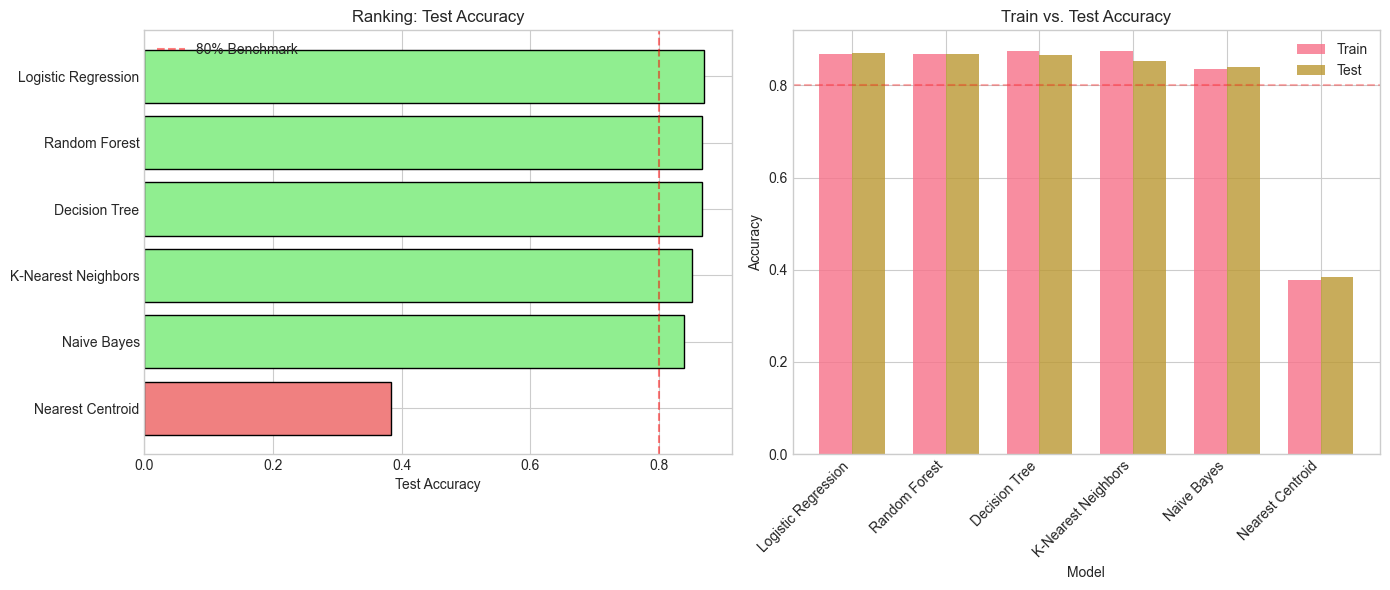


 Bestes Modell: Logistic Regression (87.05%)


In [16]:
# Visualisierung: Train vs Test
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Test Accuracy Ranking
colors = ['lightcoral' if x < 0.80 else 'lightgreen' for x in results_df['Test Accuracy']]
ax[0].barh(range(len(results_df)), results_df['Test Accuracy'], color=colors, edgecolor='black')
ax[0].set_yticks(range(len(results_df)))
ax[0].set_yticklabels(results_df['Model'])
ax[0].set_xlabel('Test Accuracy')
ax[0].set_title('Ranking: Test Accuracy')
ax[0].axvline(x=0.80, color='red', linestyle='--', alpha=0.5, label='80% Benchmark')
ax[0].legend()
ax[0].invert_yaxis()

# Plot 2: Train vs Test
x_pos = np.arange(len(results_df))
width = 0.35
ax[1].bar(x_pos - width/2, results_df['Train Accuracy'], width, label='Train', alpha=0.8)
ax[1].bar(x_pos + width/2, results_df['Test Accuracy'], width, label='Test', alpha=0.8)
ax[1].set_xlabel('Model')
ax[1].set_ylabel('Accuracy')
ax[1].set_title('Train vs. Test Accuracy')
ax[1].set_xticks(x_pos)
ax[1].set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax[1].legend()
ax[1].axhline(y=0.80, color='red', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n Bestes Modell: {results_df.iloc[0]['Model']} ({results_df.iloc[0]['Test Accuracy']:.2%})")

## Teil 6: Visualisierung - Bestes vs. Schlechtestes Modell

**Confusion Matrix:** Wo machen die Modelle Fehler?

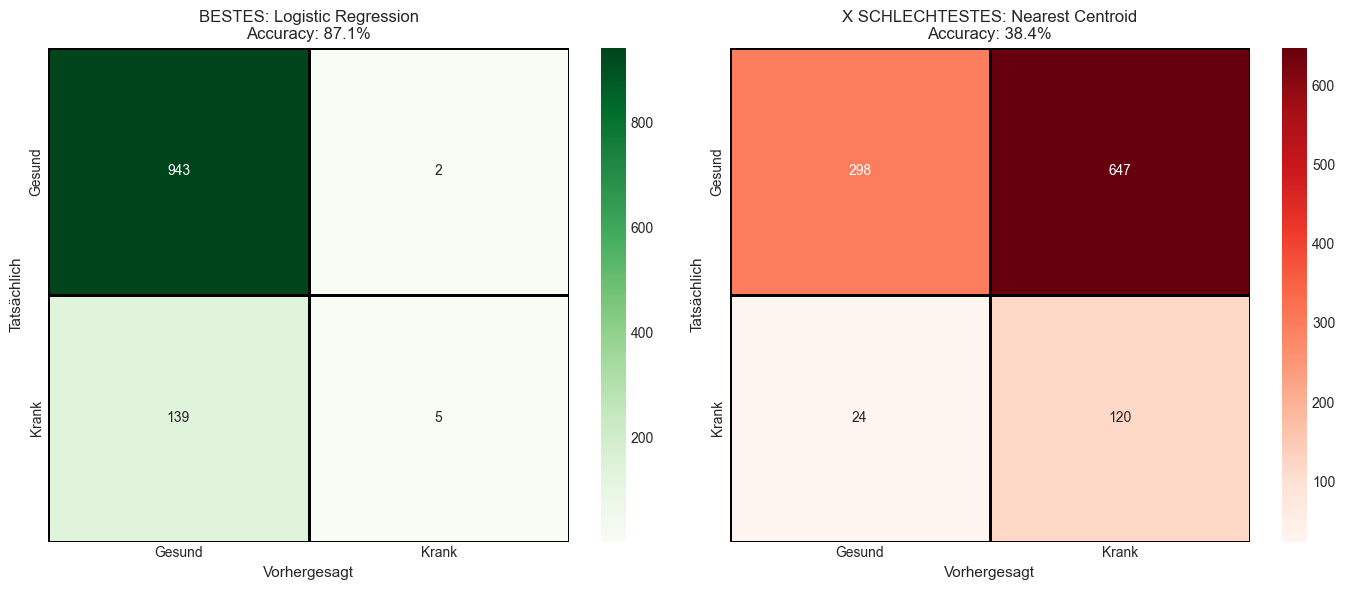


 Confusion Matrix lesen:
   - Diagonale (dunkel): Richtige Vorhersagen ✓
   - Oben rechts: Gesunde als krank erkannt (False Positive)
   - Unten links: Kranke als gesund erkannt (False Negative) !!KRITISCH!!

 Im medizinischen Kontext:
   False Negative = Kranker wird übersehen → Gefährlich!
   False Positive = Weitere Tests nötig → Weniger kritisch


In [17]:
# Bestes und Schlechtestes Modell
best_name = results_df.iloc[0]['Model']
worst_name = results_df.iloc[-1]['Model']

best_model = models[best_name]
worst_model = models[worst_name]

# Vorhersagen
y_pred_best = best_model.predict(X_test)
y_pred_worst = worst_model.predict(X_test)

# Confusion Matrices
cm_best = confusion_matrix(y_test, y_pred_best)
cm_worst = confusion_matrix(y_test, y_pred_worst)

# Visualisierung
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# BESTES Modell
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Gesund', 'Krank'], yticklabels=['Gesund', 'Krank'],
            ax=ax[0], cbar=True, linewidths=1, linecolor='black')
ax[0].set_xlabel('Vorhergesagt', fontsize=11)
ax[0].set_ylabel('Tatsächlich', fontsize=11)
ax[0].set_title(f'BESTES: {best_name}\nAccuracy: {results_df.iloc[0]["Test Accuracy"]:.1%}',
                fontsize=12)

# SCHLECHTESTES Modell
sns.heatmap(cm_worst, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Gesund', 'Krank'], yticklabels=['Gesund', 'Krank'],
            ax=ax[1], cbar=True, linewidths=1, linecolor='black')
ax[1].set_xlabel('Vorhergesagt', fontsize=11)
ax[1].set_ylabel('Tatsächlich', fontsize=11)
ax[1].set_title(f'X SCHLECHTESTES: {worst_name}\nAccuracy: {results_df.iloc[-1]["Test Accuracy"]:.1%}',
                fontsize=12)

plt.tight_layout()
plt.show()

print("\n Confusion Matrix lesen:")
print("   - Diagonale (dunkel): Richtige Vorhersagen ✓")
print("   - Oben rechts: Gesunde als krank erkannt (False Positive)")
print("   - Unten links: Kranke als gesund erkannt (False Negative) !!KRITISCH!!")
print("\n Im medizinischen Kontext:")
print("   False Negative = Kranker wird übersehen → Gefährlich!")
print("   False Positive = Weitere Tests nötig → Weniger kritisch")

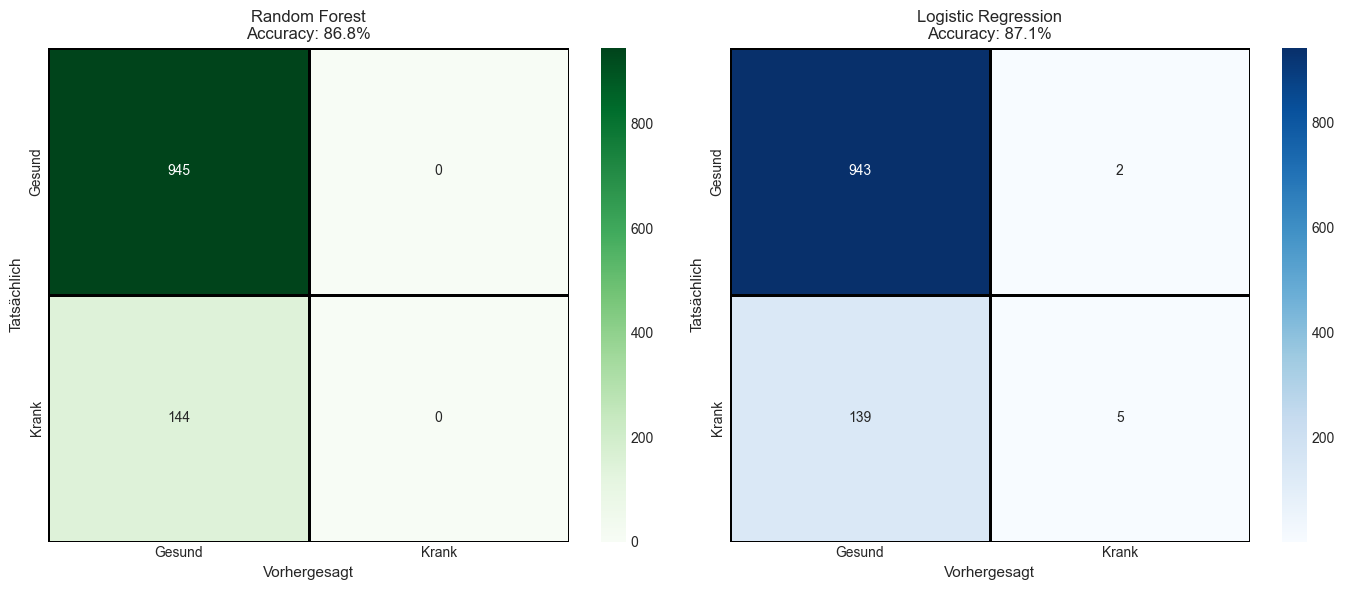


VERGLEICH: RANDOM FOREST vs. LOGISTIC REGRESSION

Random Forest Accuracy:       86.8%
Logistic Regression Accuracy: 87.1%

--- Random Forest ---
[[945   0]
 [144   0]]

--- Logistic Regression ---
[[943   2]
 [139   5]]

CONFUSION MATRIX LESEN

Die Confusion Matrix:

                 Vorhergesagt
                 Gesund   Krank

Tatsächlich
Gesund             TN       FP
Krank              FN       TP


TN = True Negative
     Gesunde Person wird korrekt als gesund erkannt.

FP = False Positive
     Gesunde Person wird fälschlicherweise als krank erkannt.

FN = False Negative
     Kranke Person wird fälschlicherweise als gesund erkannt.

TP = True Positive
     Kranke Person wird korrekt als krank erkannt.


--- Medizinischer Kontext ---

False Negative (FN):
Ein kranker Patient wird übersehen.
→ Besonders kritisch!

False Positive (FP):
Ein gesunder Patient wird als krank eingestuft.
→ Weitere Untersuchungen können notwendig sein.



In [18]:

# ============================================================
# RANDOM FOREST vs. LOGISTIC REGRESSION
# ============================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# ------------------------------------------------------------
# Modelle auswählen
# ------------------------------------------------------------

random_forest = models['Random Forest']
logistic_regression = models['Logistic Regression']


# ------------------------------------------------------------
# Vorhersagen
# ------------------------------------------------------------

y_pred_rf = random_forest.predict(X_test)
y_pred_lr = logistic_regression.predict(X_test)


# ------------------------------------------------------------
# Confusion Matrices
# ------------------------------------------------------------

cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_lr = confusion_matrix(y_test, y_pred_lr)


# ------------------------------------------------------------
# Accuracy berechnen
# ------------------------------------------------------------

accuracy_rf = (y_pred_rf == y_test).mean()
accuracy_lr = (y_pred_lr == y_test).mean()


# ------------------------------------------------------------
# Visualisierung
# ------------------------------------------------------------

fig, ax = plt.subplots(1, 2, figsize=(14, 6))


# ============================================================
# RANDOM FOREST
# ============================================================

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Gesund', 'Krank'],
    yticklabels=['Gesund', 'Krank'],
    ax=ax[0],
    cbar=True,
    linewidths=1,
    linecolor='black'
)

ax[0].set_xlabel('Vorhergesagt', fontsize=11)
ax[0].set_ylabel('Tatsächlich', fontsize=11)

ax[0].set_title(
    f'Random Forest\nAccuracy: {accuracy_rf:.1%}',
    fontsize=12
)


# ============================================================
# LOGISTIC REGRESSION
# ============================================================

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Gesund', 'Krank'],
    yticklabels=['Gesund', 'Krank'],
    ax=ax[1],
    cbar=True,
    linewidths=1,
    linecolor='black'
)

ax[1].set_xlabel('Vorhergesagt', fontsize=11)
ax[1].set_ylabel('Tatsächlich', fontsize=11)

ax[1].set_title(
    f'Logistic Regression\nAccuracy: {accuracy_lr:.1%}',
    fontsize=12
)


# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------

plt.tight_layout()
plt.show()


# ============================================================
# AUSWERTUNG
# ============================================================

print("\n" + "=" * 60)
print("VERGLEICH: RANDOM FOREST vs. LOGISTIC REGRESSION")
print("=" * 60)

print(f"\nRandom Forest Accuracy:       {accuracy_rf:.1%}")
print(f"Logistic Regression Accuracy: {accuracy_lr:.1%}")


# ------------------------------------------------------------
# Confusion Matrices ausgeben
# ------------------------------------------------------------

print("\n--- Random Forest ---")
print(cm_rf)

print("\n--- Logistic Regression ---")
print(cm_lr)


# ============================================================
# MEDIZINISCHE INTERPRETATION
# ============================================================

print("\n" + "=" * 60)
print("CONFUSION MATRIX LESEN")
print("=" * 60)

print("""
Die Confusion Matrix:

                 Vorhergesagt
                 Gesund   Krank

Tatsächlich
Gesund             TN       FP
Krank              FN       TP


TN = True Negative
     Gesunde Person wird korrekt als gesund erkannt.

FP = False Positive
     Gesunde Person wird fälschlicherweise als krank erkannt.

FN = False Negative
     Kranke Person wird fälschlicherweise als gesund erkannt.

TP = True Positive
     Kranke Person wird korrekt als krank erkannt.
""")


print("\n--- Medizinischer Kontext ---")

print("""
False Negative (FN):
Ein kranker Patient wird übersehen.
→ Besonders kritisch!

False Positive (FP):
Ein gesunder Patient wird als krank eingestuft.
→ Weitere Untersuchungen können notwendig sein.
""")


In [19]:
# Detailanalyse: False Negatives
tn_best, fp_best, fn_best, tp_best = cm_best.ravel()
tn_worst, fp_worst, fn_worst, tp_worst = cm_worst.ravel()

print("\n MEDIZINISCHE BEWERTUNG:")
print("="*70)
print(f"\n{best_name}:")
print(f"   + Kranke richtig erkannt: {tp_best} von {tp_best + fn_best} ({tp_best/(tp_best+fn_best)*100:.1f}%)")
print(f"   - Kranke übersehen (FN): {fn_best}")

print(f"\n{worst_name}:")
print(f"   + Kranke richtig erkannt: {tp_worst} von {tp_worst + fn_worst} ({tp_worst/(tp_worst+fn_worst)*100:.1f}%)")
print(f"   - Kranke übersehen (FN): {fn_worst}")

print("\nFazit: Das beste Modell übersieht weniger kranke Patienten!")


 MEDIZINISCHE BEWERTUNG:

Logistic Regression:
   + Kranke richtig erkannt: 5 von 144 (3.5%)
   - Kranke übersehen (FN): 139

Nearest Centroid:
   + Kranke richtig erkannt: 120 von 144 (83.3%)
   - Kranke übersehen (FN): 24

Fazit: Das beste Modell übersieht weniger kranke Patienten!


In [20]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [21]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[878  67]
 [114  30]]
              precision    recall  f1-score   support

           0       0.89      0.93      0.91       945
           1       0.31      0.21      0.25       144

    accuracy                           0.83      1089
   macro avg       0.60      0.57      0.58      1089
weighted avg       0.81      0.83      0.82      1089



# von ML 2

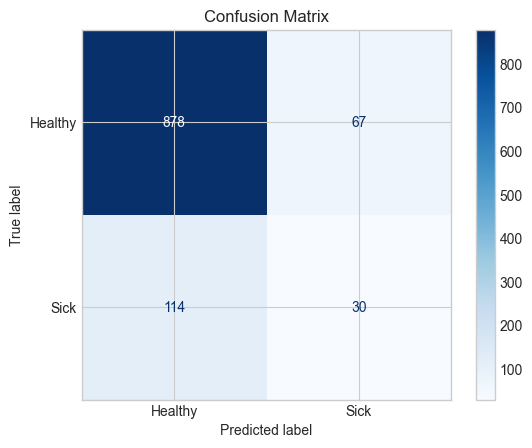

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Make predictions
y_pred = model.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['Healthy', 'Sick'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [23]:
from sklearn.metrics import classification_report

# Calculate all metrics
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.93      0.91       945
           1       0.31      0.21      0.25       144

    accuracy                           0.83      1089
   macro avg       0.60      0.57      0.58      1089
weighted avg       0.81      0.83      0.82      1089



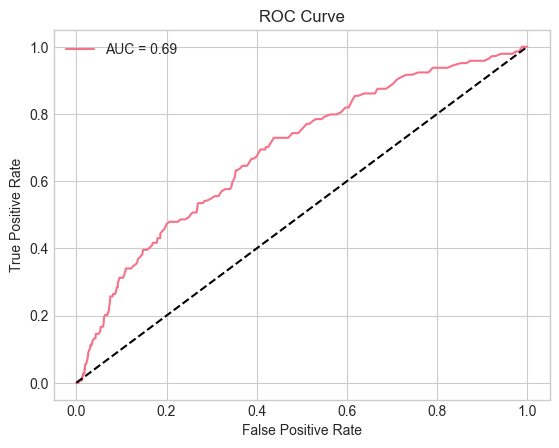

In [24]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probabilities
y_proba = model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Plot
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [25]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

# Define model
model = DecisionTreeClassifier(max_depth=5, random_state=42)

# 5-Fold Cross-Validation
scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

print(f"Scores: {scores}")
print(f"Mean Accuracy: {scores.mean():.3f} (+/- {scores.std():.3f})")

Scores: [0.85307622 0.86764706 0.86488971 0.86397059 0.86305147]
Mean Accuracy: 0.863 (+/- 0.005)


In [26]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# Define parameter grid
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Grid Search with Cross-Validation
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1  # Parallel computation
)

# Training
grid_search.fit(X_train, y_train)

# Best parameters
print(f"Best params: {grid_search.best_params_}")
print(f"Best score: {grid_search.best_score_:.3f}")

Best params: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best score: 0.192


In [27]:
# All results as DataFrame
results = pd.DataFrame(grid_search.cv_results_)

# Top 5 combinations
results[['params', 'mean_test_score', 'std_test_score']] \
    .sort_values('mean_test_score', ascending=False) \
    .head()

# Use best model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Final evaluation
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.96      0.91       945
           1       0.23      0.08      0.11       144

    accuracy                           0.84      1089
   macro avg       0.55      0.52      0.51      1089
weighted avg       0.79      0.84      0.81      1089



In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # Only transform!

In [29]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_train)

In [30]:
# Features with high correlation to target
correlation = (
    df_ML.select_dtypes(include='number')
      .corr()['DEPT']
      .abs()
      .sort_values(ascending=False)
)

top_features = correlation.head(20).index.tolist()
top_features

['DEPT',
 'RIDAGEYR',
 'DMDMARTZ',
 'RIAGENDR',
 'BMXBMI',
 'OCD150',
 'ASH',
 'MEMPW',
 'DMDEDUC2']

In [31]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Feature Importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

feature_importance

,feature,importance
4,BMXBMI,0.233672
6,ASH,0.217267
1,RIDAGEYR,0.187963
7,MEMPW,0.175267
2,DMDEDUC2,0.069602
3,DMDMARTZ,0.046443
5,OCD150,0.042286
0,RIAGENDR,0.027499


In [32]:
from sklearn.feature_selection import SelectKBest, f_classif

# Select top 10 features
selector = SelectKBest(score_func=f_classif, k=10)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Which features were selected?
selected_features = X_train.columns[selector.get_support()]
print(f"Selected features: {selected_features.tolist()}")

# Train model with selected features
model = LogisticRegression(max_iter=1000)
model.fit(X_train_selected, y_train)

Selected features: ['RIAGENDR', 'RIDAGEYR', 'DMDEDUC2', 'DMDMARTZ', 'BMXBMI', 'OCD150', 'ASH', 'MEMPW']


/Users/helmut/miniconda3/envs/MedViz/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=10 is greater than n_features=8. All the features will be returned.
  warnings.warn(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [33]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest
from sklearn.ensemble import RandomForestClassifier

# Create pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(k=10)),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Training
pipeline.fit(X_train, y_train)

# Prediction
y_pred = pipeline.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred))

/Users/helmut/miniconda3/envs/MedViz/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=10 is greater than n_features=8. All the features will be returned.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.87      0.99      0.93       945
           1       0.35      0.04      0.07       144

    accuracy                           0.86      1089
   macro avg       0.61      0.52      0.50      1089
weighted avg       0.80      0.86      0.81      1089



In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

categorical_features = ['DMDEDUC2', 'DMDMARTZ', 'OCD150']
numeric_features = ['RIAGENDR', 'RIDAGEYR', 'BMXBMI', 'ASH', 'MEMPW']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=42
    ))
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['RIAGENDR','RIDAGEYR','DMDEDUC2',...,'OCD150','ASH','MEMPW']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaini

Accuracy: 0.8246097337006428

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.88      0.92      0.90       945
        Sick       0.28      0.22      0.25       144

    accuracy                           0.82      1089
   macro avg       0.58      0.57      0.57      1089
weighted avg       0.81      0.82      0.81      1089



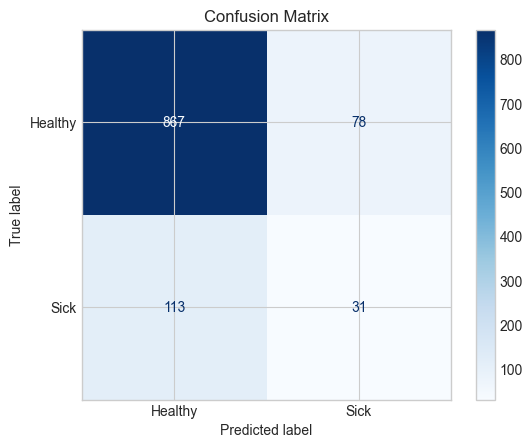

In [35]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score
)
import matplotlib.pyplot as plt

# Vorhersagen auf Testdaten
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=['Healthy', 'Sick']
))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Healthy', 'Sick']
)

disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


VERGLEICH: RANDOM FOREST vs. LOGISTIC REGRESSION


                  Random Forest  Logistic Regression
Accuracy                  0.868                0.871
Precision (Sick)          0.000                0.714
Recall (Sick)             0.000                0.035
F1-Score (Sick)           0.000                0.066

RANDOM FOREST - CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Healthy       0.87      1.00      0.93       945
        Sick       0.00      0.00      0.00       144

    accuracy                           0.87      1089
   macro avg       0.43      0.50      0.46      1089
weighted avg       0.75      0.87      0.81      1089


LOGISTIC REGRESSION - CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Healthy       0.87      1.00      0.93       945
        Sick       0.71      0.03      0.07       144

    accuracy                           0.87      1089
   macro avg       0.79      0.52      0.50      1089


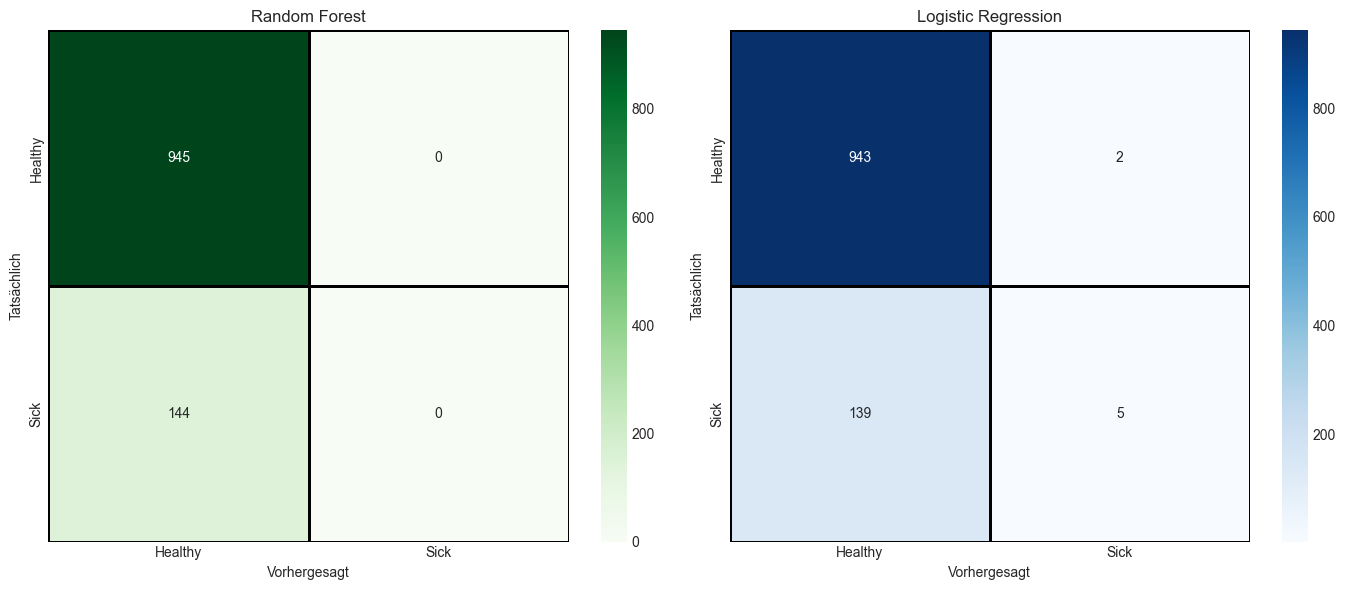

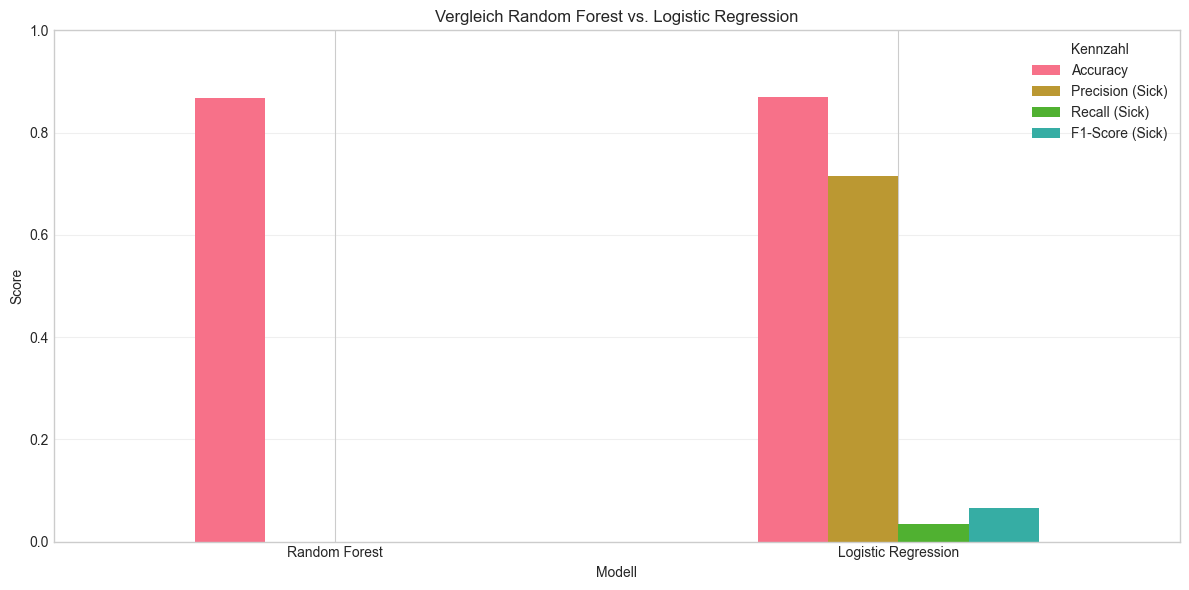


MEDIZINISCHER VERGLEICH

Recall Sick - Random Forest:       0.0%
Recall Sick - Logistic Regression: 3.5%

→ Logistic Regression erkennt mehr tatsächlich kranke Personen.

F1-Score Sick - Random Forest:       0.0%
F1-Score Sick - Logistic Regression: 6.6%


In [36]:

# ============================================================
# VERGLEICH: RANDOM FOREST vs. LOGISTIC REGRESSION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# Modelle auswählen
# ============================================================

random_forest = models['Random Forest']
logistic_regression = models['Logistic Regression']


# ============================================================
# Vorhersagen
# ============================================================

y_pred_rf = random_forest.predict(X_test)
y_pred_lr = logistic_regression.predict(X_test)


# ============================================================
# Kennzahlen berechnen
# ============================================================

comparison = pd.DataFrame({

    'Random Forest': [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf, zero_division=0),
        recall_score(y_test, y_pred_rf, zero_division=0),
        f1_score(y_test, y_pred_rf, zero_division=0)
    ],

    'Logistic Regression': [
        accuracy_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr, zero_division=0),
        recall_score(y_test, y_pred_lr, zero_division=0),
        f1_score(y_test, y_pred_lr, zero_division=0)
    ]

}, index=[
    'Accuracy',
    'Precision (Sick)',
    'Recall (Sick)',
    'F1-Score (Sick)'
])


# ============================================================
# Ergebnisse anzeigen
# ============================================================

print("\n" + "=" * 65)
print("VERGLEICH: RANDOM FOREST vs. LOGISTIC REGRESSION")
print("=" * 65)

print("\n")
print(comparison.round(3))


# ============================================================
# Classification Reports
# ============================================================

print("\n" + "=" * 65)
print("RANDOM FOREST - CLASSIFICATION REPORT")
print("=" * 65)

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=['Healthy', 'Sick'],
        zero_division=0
    )
)


print("\n" + "=" * 65)
print("LOGISTIC REGRESSION - CLASSIFICATION REPORT")
print("=" * 65)

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=['Healthy', 'Sick'],
        zero_division=0
    )
)


# ============================================================
# Confusion Matrices
# ============================================================

cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_lr = confusion_matrix(y_test, y_pred_lr)


fig, ax = plt.subplots(1, 2, figsize=(14, 6))


# ------------------------------------------------------------
# Random Forest
# ------------------------------------------------------------

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Healthy', 'Sick'],
    yticklabels=['Healthy', 'Sick'],
    ax=ax[0],
    linewidths=1,
    linecolor='black'
)

ax[0].set_title('Random Forest')
ax[0].set_xlabel('Vorhergesagt')
ax[0].set_ylabel('Tatsächlich')


# ------------------------------------------------------------
# Logistic Regression
# ------------------------------------------------------------

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Healthy', 'Sick'],
    yticklabels=['Healthy', 'Sick'],
    ax=ax[1],
    linewidths=1,
    linecolor='black'
)

ax[1].set_title('Logistic Regression')
ax[1].set_xlabel('Vorhergesagt')
ax[1].set_ylabel('Tatsächlich')


plt.tight_layout()
plt.show()


# ============================================================
# Balkendiagramm: Kennzahlen vergleichen
# ============================================================

comparison.T.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Vergleich Random Forest vs. Logistic Regression')
plt.ylabel('Score')
plt.xlabel('Modell')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title='Kennzahl')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# Medizinisch besonders wichtig:
# Recall für Sick
# ============================================================

rf_recall = recall_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

lr_recall = recall_score(
    y_test,
    y_pred_lr,
    zero_division=0
)


print("\n" + "=" * 65)
print("MEDIZINISCHER VERGLEICH")
print("=" * 65)

print(
    f"\nRecall Sick - Random Forest:       {rf_recall:.1%}"
)

print(
    f"Recall Sick - Logistic Regression: {lr_recall:.1%}"
)


if rf_recall > lr_recall:

    print(
        "\n→ Random Forest erkennt mehr tatsächlich kranke Personen."
    )

elif lr_recall > rf_recall:

    print(
        "\n→ Logistic Regression erkennt mehr tatsächlich kranke Personen."
    )

else:

    print(
        "\n→ Beide Modelle haben den gleichen Recall für Sick."
    )


# ============================================================
# F1-Score vergleichen
# ============================================================

rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

lr_f1 = f1_score(
    y_test,
    y_pred_lr,
    zero_division=0
)


print(
    f"\nF1-Score Sick - Random Forest:       {rf_f1:.1%}"
)

print(
    f"F1-Score Sick - Logistic Regression: {lr_f1:.1%}"
)



In [37]:
print("Anzahl tatsächliche Gesunde:", sum(y_test == 0))
print("Anzahl tatsächliche Kranke:", sum(y_test == 1))

print("Erkannte Gesunde:", sum((y_test == 0) & (y_pred == 0)))
print("Erkannte Kranke:", sum((y_test == 1) & (y_pred == 1)))

print("Kranke insgesamt:", sum(y_test == 1))

Anzahl tatsächliche Gesunde: 945
Anzahl tatsächliche Kranke: 144
Erkannte Gesunde: 867
Erkannte Kranke: 31
Kranke insgesamt: 144


## Zusammenfassung

**Heute gelernt:**

✅ **ML in der Medizin:** Computer kann Herzkrankheiten mit 85.23% Genauigkeit erkennen

✅ **Risikofaktoren:** Feature Selection zeigt wichtigste medizinische Indikatoren

✅ **Modellvergleich:** In diesem Fall (basierend auf den Datensatz) ist 85 "Logistic Regression" am besten

✅ **Confusion Matrix:** Zeigt wo Fehler passieren - False Negatives sind kritisch!

**Nächste Woche:**
- Precision, Recall, F1-Score im Detail
- Wie minimiere ich False Negatives?
- Feature Engineering

In [ ]:
!streamlit run dep_app.py

2026-09-17 17:57:35.496 Uvicorn server started on :::8503

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8503
  Network URL: http://192.168.1.103:8503

  Help agents write better Streamlit apps?
  Install the official Streamlit skills by running streamlit skills in your terminal.

  For better performance, install the Watchdog module:

  $ xcode-select --install
  $ pip install watchdog
            
/Users/helmut/Documents/Fernstudium/M12 Wahlfach Explorative Datenanalyse/NHANES_Depression/dep_app.py:643: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([
